In [1]:
import cv2
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Get the absolute path to your project's root directory
# Assuming your notebook is in 'notebooks/', this moves up one level
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the sys.path if it's not already there
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now you can import your modules
from services.image_ops import process_image
from services.digit_utils import extract_and_clean_cells
from models.predict import predict_sudoku_grid, predict_single_cell
from services.sudoku_solver import SudokuSolver

In [25]:
arr = process_image(r"D:\PYTON PROGRAMMING\SUDOKU SOLVER\image\images.png")

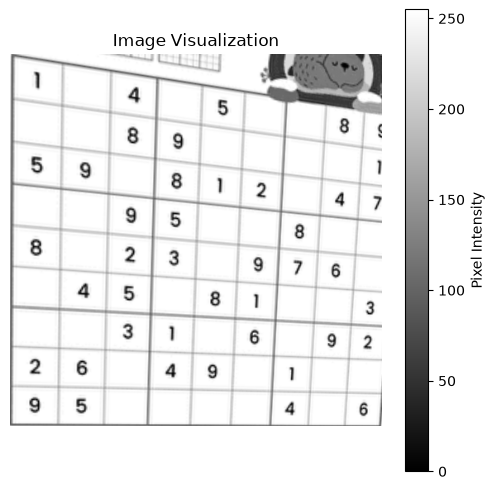

In [26]:
import matplotlib.pyplot as plt

def plot_image(array):
    """
    Plots a 2D numpy array as an image using matplotlib.
    """
    plt.figure(figsize=(6, 6))
    # cmap='gray' is used for grayscale images
    # vmin=0, vmax=255 ensures the scale is correct for uint8 data
    plt.imshow(array, cmap='gray', vmin=0, vmax=255)
    plt.colorbar(label='Pixel Intensity')
    plt.title("Image Visualization")
    plt.axis('off')  # Hides the axes for a cleaner look
    plt.show()

# Usage:
plot_image(arr)

In [5]:
arr.shape

(450, 450)

---

In [6]:
cleaned_cells = extract_and_clean_cells(arr)
print("Total cells:", len(cleaned_cells))
print("Shape of first cell:", cleaned_cells[0].shape)
print("All cells 50x50?", all(c.shape == (50, 50) for c in cleaned_cells))

Total cells: 81
Shape of first cell: (50, 50)
All cells 50x50? True


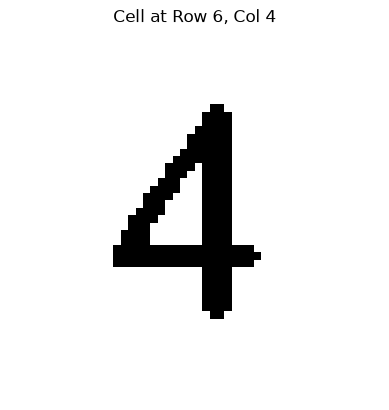

In [7]:
target_cell = cleaned_cells[58]

# Visualize this specific cell
import matplotlib.pyplot as plt
plt.imshow(target_cell, cmap='gray', vmin=0, vmax=1)
plt.title("Cell at Row 6, Col 4")
plt.axis('off')
plt.show()

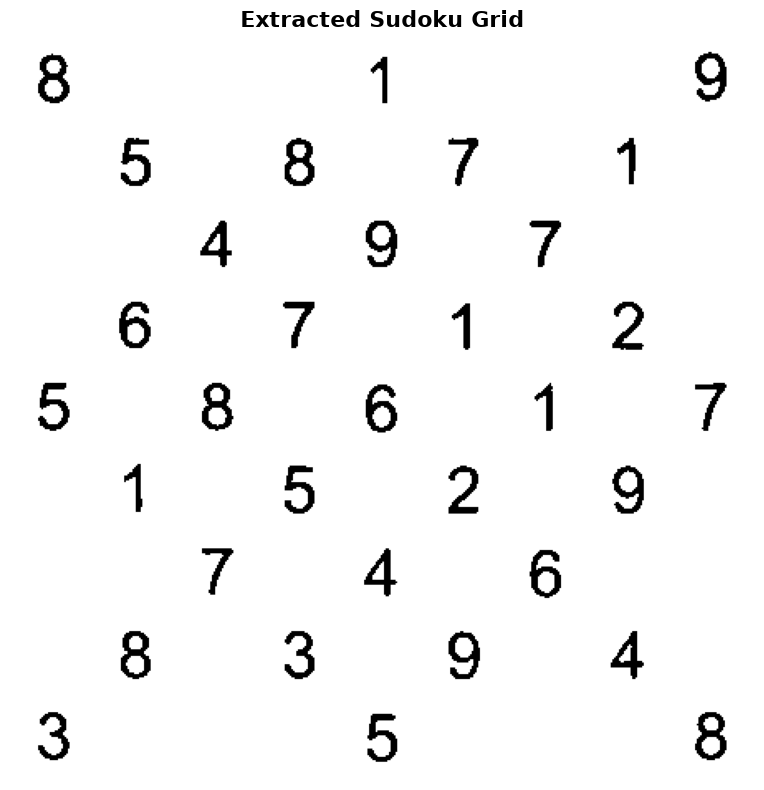

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sudoku_grid(cleaned_cells):
    """
    Stitches 81 cleaned_cells (50x50 arrays) into a single 9x9 grid 
    and displays it using matplotlib.
    """
    # 1. Reshape the list of 81 cells into a 9x9 grid structure
    grid_rows = []
    for i in range(9):
        # Slice the list to get the 9 cells for this row
        row_cells = cleaned_cells[i*9 : (i+1)*9]
        # Concatenate horizontally
        grid_rows.append(np.hstack(row_cells))
    
    # 2. Concatenate all rows vertically to create the full board
    full_board = np.vstack(grid_rows)
    
    # 3. Plotting
    plt.figure(figsize=(8, 8))
    # vmin=0, vmax=1 ensures 0 (ink) is black and 1 (bg) is white
    plt.imshow(full_board, cmap='gray', vmin=0, vmax=1)
    
    plt.title("Extracted Sudoku Grid", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sudoku_grid(cleaned_cells)

In [9]:
cleaned_cells[0][0]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=uint8)

In [10]:
from tensorflow.keras.models import load_model
MODEL = load_model(r"D:\PYTON PROGRAMMING\SUDOKU SOLVER\models\emnist_digit_cnn.keras")

In [11]:
sudoku_predictions = predict_sudoku_grid(cleaned_cells, MODEL)

In [12]:
output = predict_single_cell(target_cell, MODEL)
output

4

In [13]:
grid_9x9 = [sudoku_predictions[i*9 : (i+1)*9] for i in range(9)]

# Print to verify
for row in grid_9x9:
    print(row)

[8, 0, 0, 0, 1, 0, 0, 0, 9]
[0, 5, 0, 8, 0, 7, 0, 1, 0]
[0, 0, 4, 0, 9, 0, 7, 0, 0]
[0, 0, 0, 7, 0, 1, 0, 2, 0]
[5, 0, 8, 0, 6, 0, 1, 0, 7]
[0, 1, 0, 5, 0, 2, 0, 9, 0]
[0, 0, 7, 0, 4, 0, 6, 0, 0]
[0, 8, 0, 3, 0, 9, 0, 4, 0]
[3, 0, 0, 0, 5, 0, 0, 0, 8]


In [14]:
solver = SudokuSolver(grid_9x9)

# 3. Call the solver
if solver.helper(0, 0):
    print("Solved!")
    # Access the solved grid here
    solved_grid = solver.sud 
else:
    print("Grid is logically impossible!")

Solved!


# Train the model well